In [4]:
# ==========================================
# IMPORTS & SETUP
# ==========================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import math

# Zorg ervoor dat matplotlib figuren netjes in de notebook worden weergegeven
%matplotlib inline

Aantal gevonden bestanden: 10

Afbeelding ingeladen: 2021-04-27-01-13-33-862-Sei-Torsk-69.000.bmp
Resolutie afbeelding: 1024x1470 (Breedte x Hoogte)


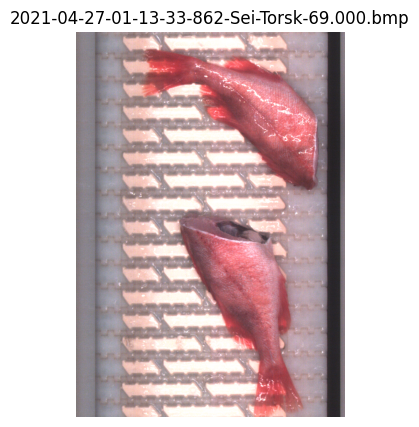

In [19]:
# Het absolute pad naar map met 2 vissen ('r' voor raw string in Windows)
dataset_path = r'C:\0 School\2025-26\Semester 2\3 Computervisie\Lab6-Project Marelec v2\6_marelec_project\1_data\Marelec_sample\2'

# Zoek alle bestanden in deze map.
image_paths = glob.glob(os.path.join(dataset_path, '*.*'))
print(f"Aantal gevonden bestanden: {len(image_paths)}\n")

# Controle 1: Hebben we bestanden gevonden?
if len(image_paths) == 0:
    print("Fout: Geen afbeeldingen gevonden")
else:    
    # Controle 2: Kunnen we een afbeelding inlezen?
    test_path = image_paths[0]
    test_img = cv2.imread(test_path)
    
    if test_img is None:
        print(f"Fout: Kon het bestand '{test_path}' niet inlezen")
    else:
        print(f"Afbeelding ingeladen: {os.path.basename(test_path)}")
        print(f"Resolutie afbeelding: {test_img.shape[1]}x{test_img.shape[0]} (Breedte x Hoogte)")
        
        # Laat beeld zien ter controle.
        test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(10, 5))
        plt.imshow(test_img_rgb)
        plt.title(f"{os.path.basename(test_path)}")
        plt.axis('off')
        plt.show()

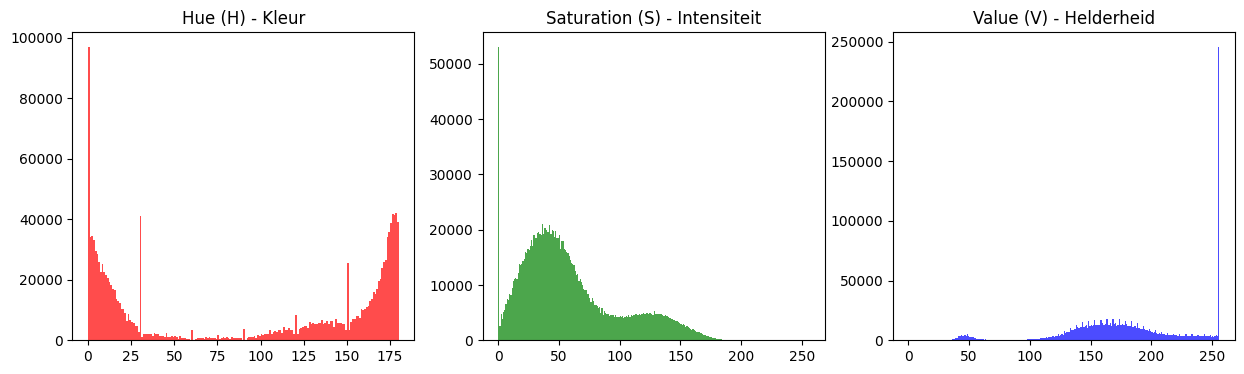

Meest voorkomende Hue waarden: [178 176 177  30 179 175 174   2   1 173]
Meest voorkomende Saturation waarden: [36 42 38 44 39 45 47 40 33 41]
Gemiddelde Saturation (S): 60
Gemiddelde Value (V): 180


In [ ]:
# Gebruik 'test_path' uit vorige cel
img = cv2.imread(test_path)
hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Splits kanalen
h, s, v = cv2.split(hsv_img)

# Visualiseer de histogrammen
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.hist(h.ravel(), bins=180, range=[0, 180], color='red', alpha=0.7)
plt.title('Hue (H) - Kleur')

plt.subplot(1, 3, 2)
plt.hist(s.ravel(), bins=256, range=[0, 256], color='green', alpha=0.7)
plt.title('Saturation (S) - Intensiteit')

plt.subplot(1, 3, 3)
plt.hist(v.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
plt.title('Value (V) - Helderheid')
plt.show()

# We zoeken de meest voorkomende waarden (pieken in de data)
hist_h = cv2.calcHist([hsv_img], [0], None, [180], [0, 180]).flatten()
hist_s = cv2.calcHist([hsv_img], [1], None, [256], [0, 256]).flatten()

# Sorteer bins van hoog naar laag (negeer bin 0, dat is vaak puur zwart/schaduw)
top_h_bins = np.argsort(hist_h)[::-1]
top_h_bins = top_h_bins[top_h_bins > 0][:10] # Pak de top 10 (zonder 0)

top_s_bins = np.argsort(hist_s)[::-1]
top_s_bins = top_s_bins[top_s_bins > 0][:10]

print(f"Meest voorkomende Hue waarden: {top_h_bins}")
print(f"Meest voorkomende Saturation waarden: {top_s_bins}")
print("Gemiddelde Saturation (S):", int(np.mean(s[s > 0])))
print("Gemiddelde Value (V):", int(np.mean(v[v > 0])))